# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Penguin Species Dataset](https://www.kaggle.com/datasets/srisyra02/penguin-species-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Penguin Species Prediction Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


## last Five row

In [4]:
df.tail()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
995,Adelie,Dream,41.5,20.5,182.0,3931.0,Male
996,Gentoo,Biscoe,46.6,14.7,224.0,5050.0,Female
997,Adelie,Dream,36.4,16.6,183.0,3572.0,Male
998,Gentoo,Biscoe,47.9,15.0,213.0,5414.0,Female
999,Adelie,Dream,38.5,18.9,187.0,4316.0,Female


## Shape of our dataset

In [5]:
df.shape

(1000, 7)

## List out all columns

In [6]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            1000 non-null   object 
 1   island             1000 non-null   object 
 2   culmen_length_mm   990 non-null    float64
 3   culmen_depth_mm    990 non-null    float64
 4   flipper_length_mm  990 non-null    float64
 5   body_mass_g        990 non-null    float64
 6   sex                990 non-null    object 
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64

## Handle Null Values

In [10]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])
cat_imputer = SimpleImputer(strategy='most_frequent')
df[['sex']] = cat_imputer.fit_transform(df[['sex']])

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.817600,17.340200,199.182000,4101.098000
std,5.283342,1.770734,13.112315,702.141434
min,32.400000,13.000000,175.000000,2830.000000
25%,39.000000,15.800000,189.000000,3593.500000
50%,43.800000,17.800000,195.000000,3882.000000
75%,48.300000,18.700000,211.000000,4580.500000
max,56.000000,21.400000,235.000000,6317.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

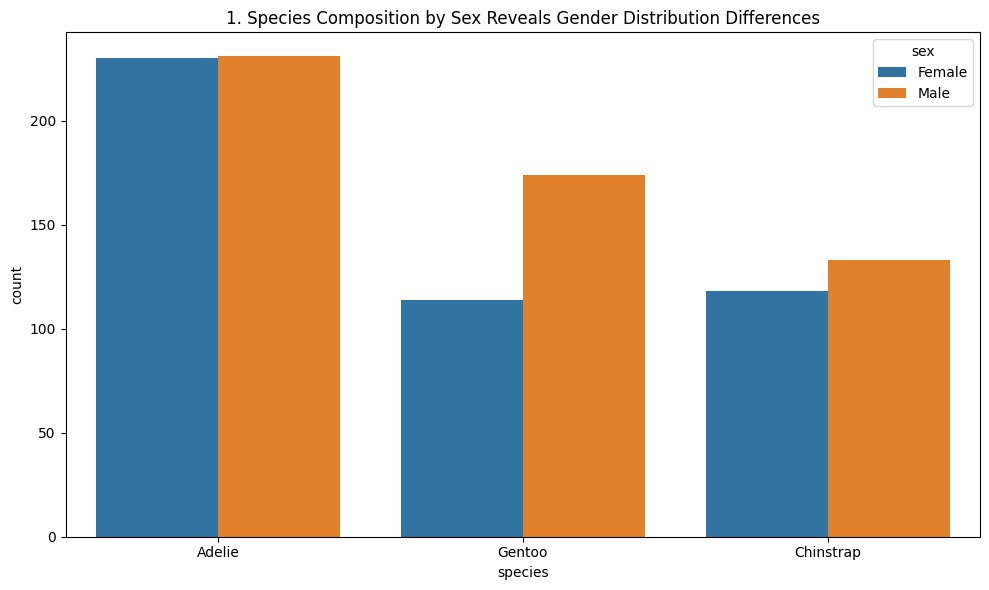

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='species', hue='sex')
plt.title(f'{plot_no}. Species Composition by Sex Reveals Gender Distribution Differences')
show_fig()
plot_no += 1

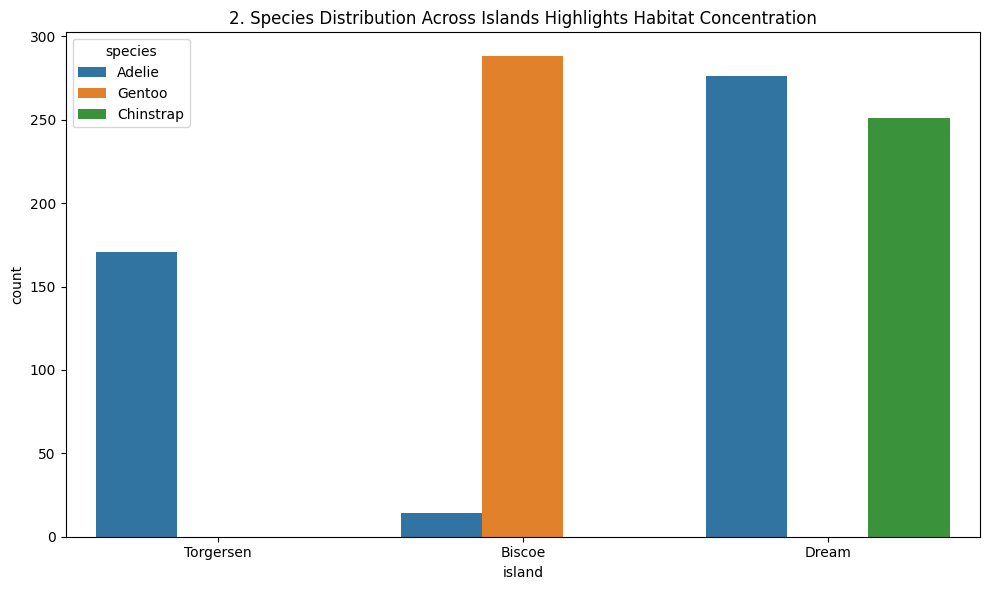

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='island', hue='species')
plt.title(f'{plot_no}. Species Distribution Across Islands Highlights Habitat Concentration')
show_fig()
plot_no += 1

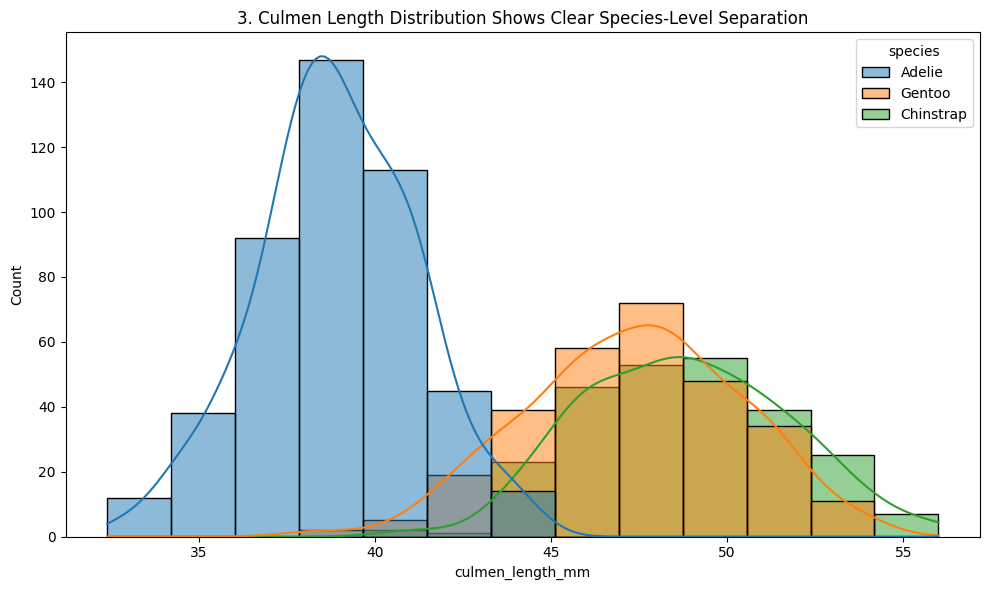

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='culmen_length_mm', hue='species', kde=True)
plt.title(f'{plot_no}. Culmen Length Distribution Shows Clear Species-Level Separation')
show_fig()
plot_no += 1

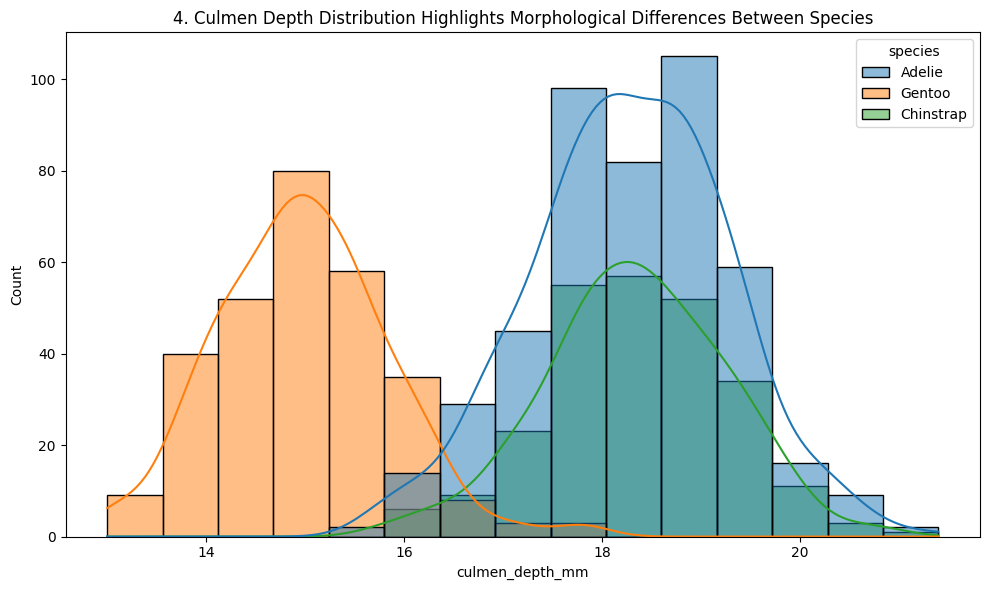

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='culmen_depth_mm', hue='species', kde=True)
plt.title(f'{plot_no}. Culmen Depth Distribution Highlights Morphological Differences Between Species')
show_fig()
plot_no += 1

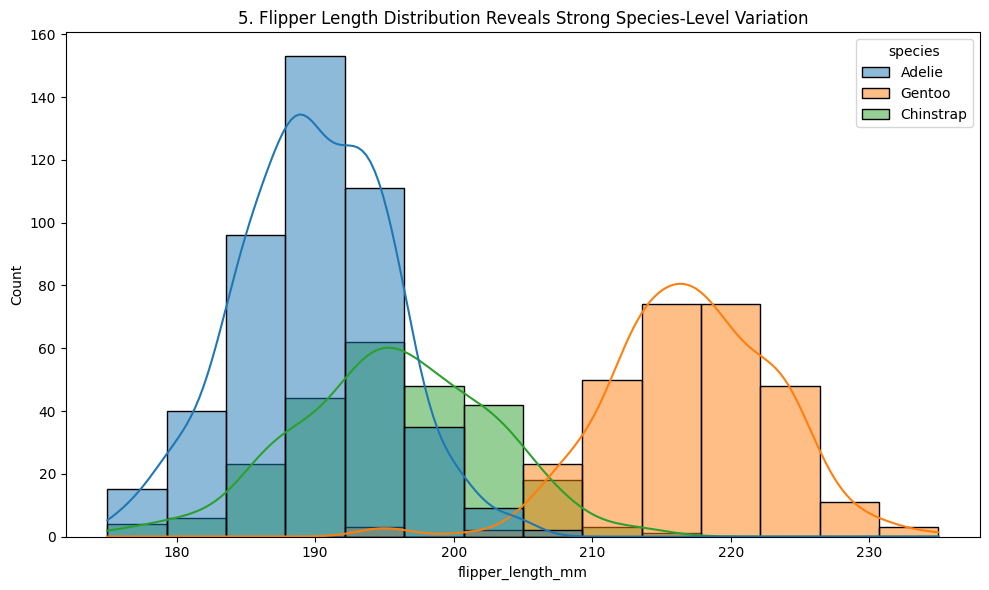

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='flipper_length_mm', hue='species', kde=True)
plt.title(f'{plot_no}. Flipper Length Distribution Reveals Strong Species-Level Variation')
show_fig()
plot_no += 1

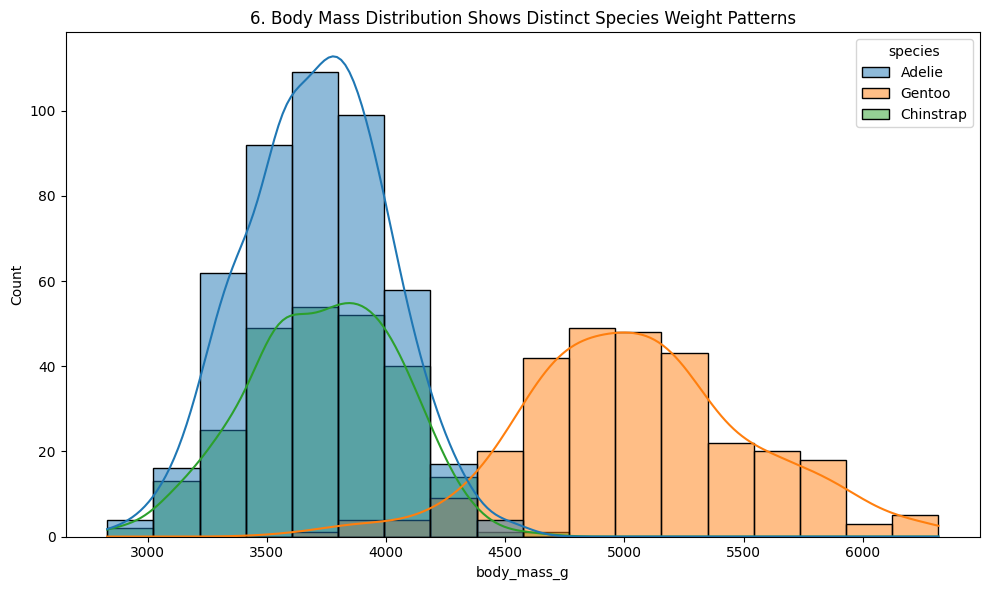

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='body_mass_g', hue='species', kde=True)
plt.title(f'{plot_no}. Body Mass Distribution Shows Distinct Species Weight Patterns')
show_fig()
plot_no += 1

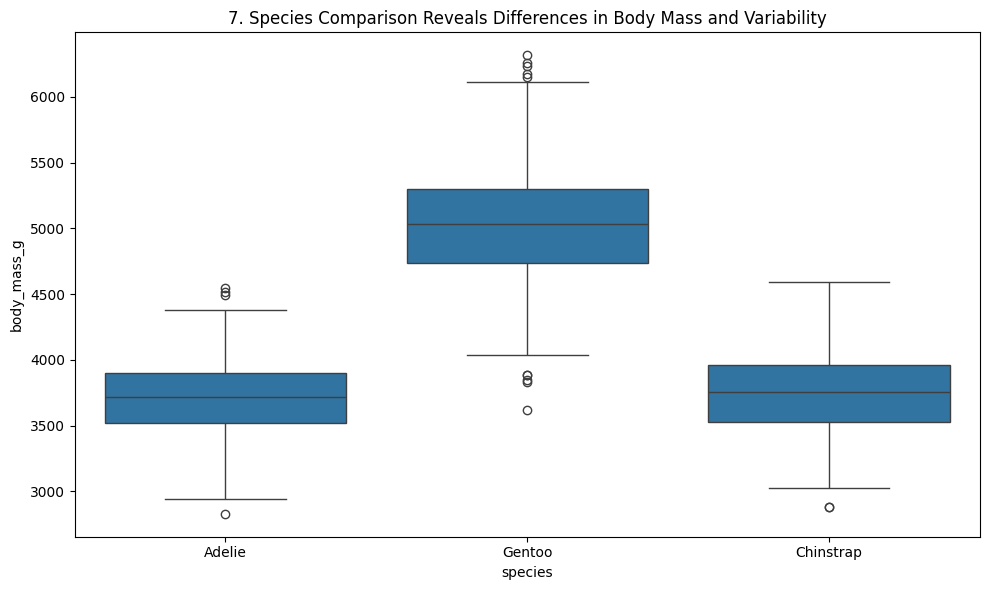

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='body_mass_g')
plt.title(f'{plot_no}. Species Comparison Reveals Differences in Body Mass and Variability')
show_fig()
plot_no += 1

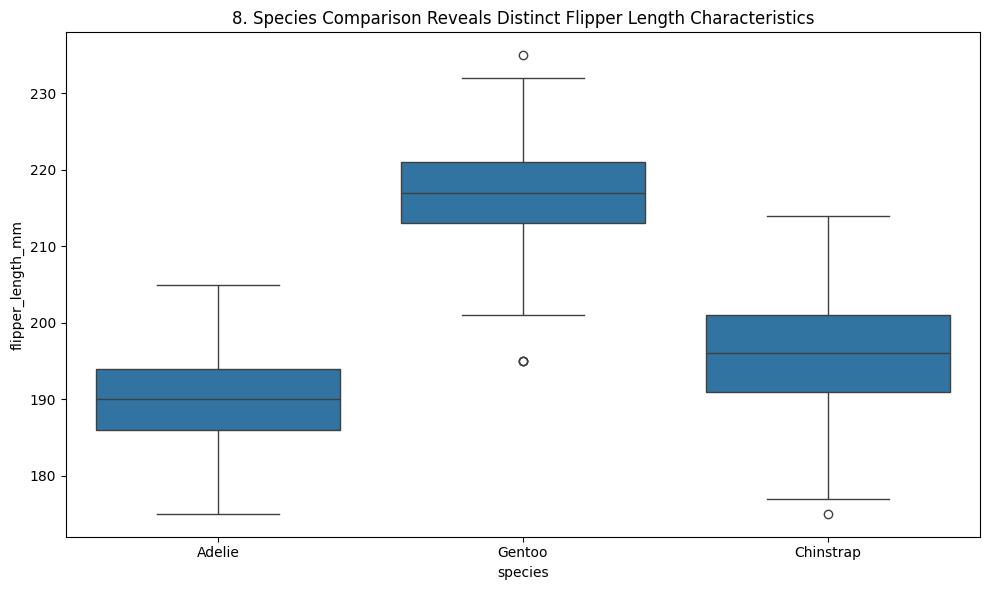

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title(f'{plot_no}. Species Comparison Reveals Distinct Flipper Length Characteristics')
show_fig()
plot_no += 1

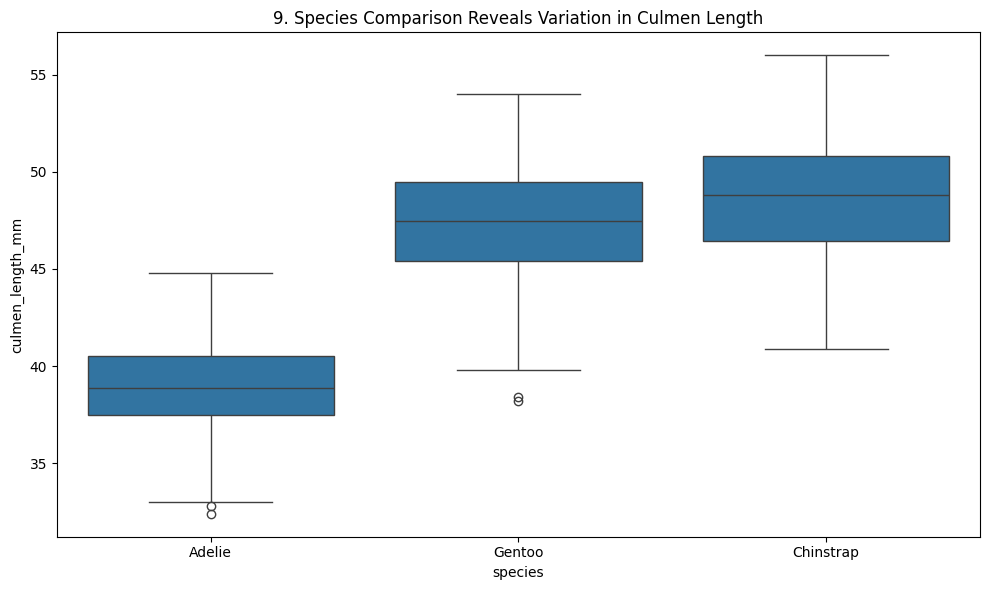

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='culmen_length_mm')
plt.title(f'{plot_no}. Species Comparison Reveals Variation in Culmen Length')
show_fig()
plot_no += 1

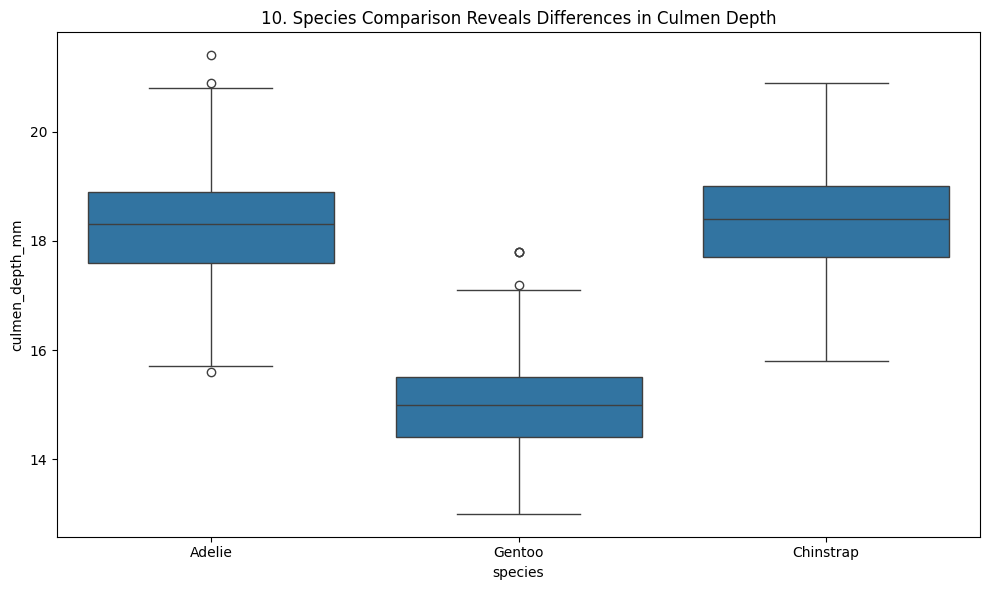

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='culmen_depth_mm')
plt.title(f'{plot_no}. Species Comparison Reveals Differences in Culmen Depth')
show_fig()
plot_no += 1

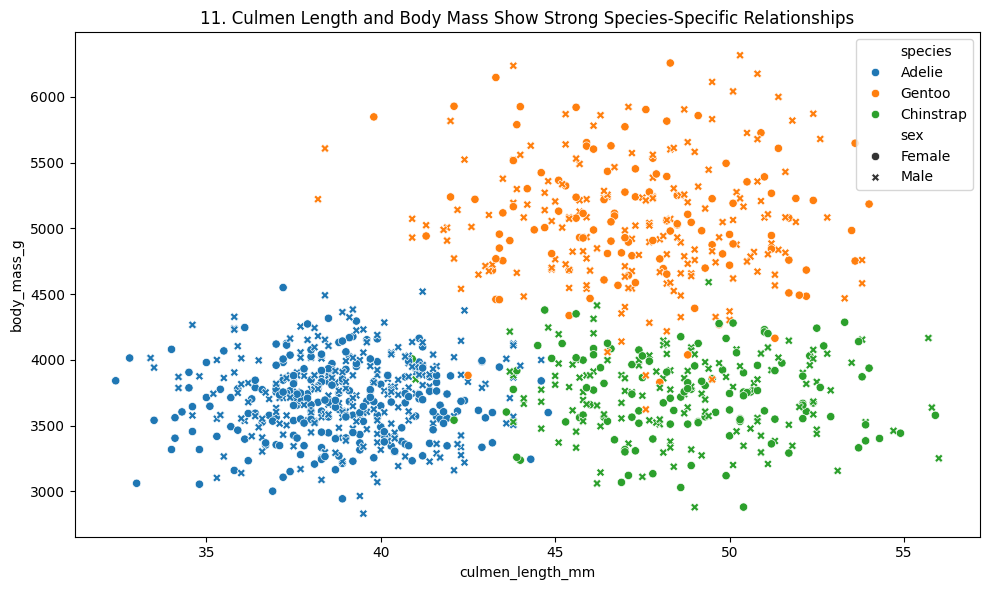

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='culmen_length_mm', y='body_mass_g', hue='species', style='sex')
plt.title(f'{plot_no}. Culmen Length and Body Mass Show Strong Species-Specific Relationships')
show_fig()
plot_no += 1

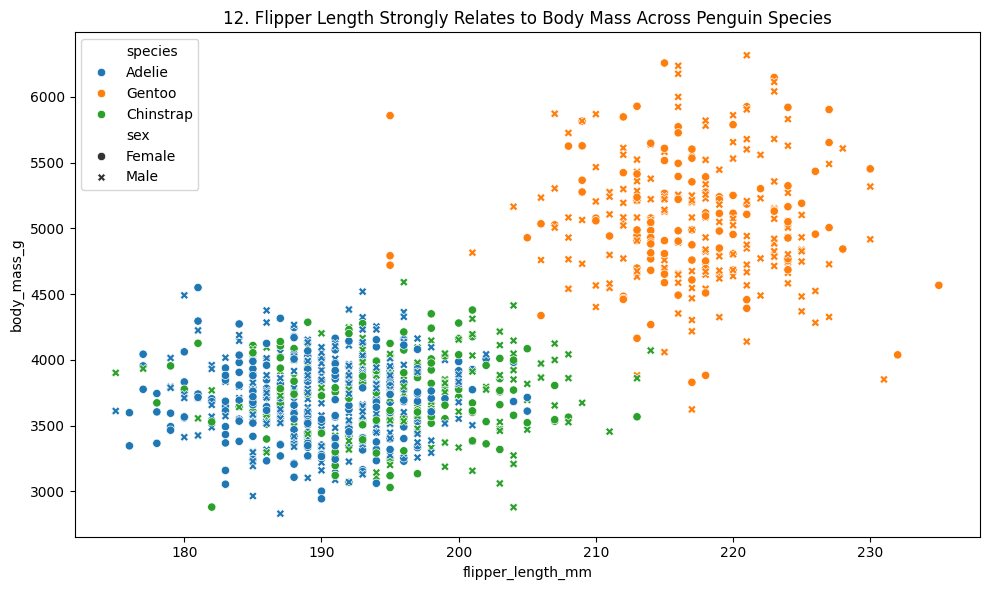

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', style='sex')
plt.title(f'{plot_no}. Flipper Length Strongly Relates to Body Mass Across Penguin Species')
show_fig()
plot_no += 1

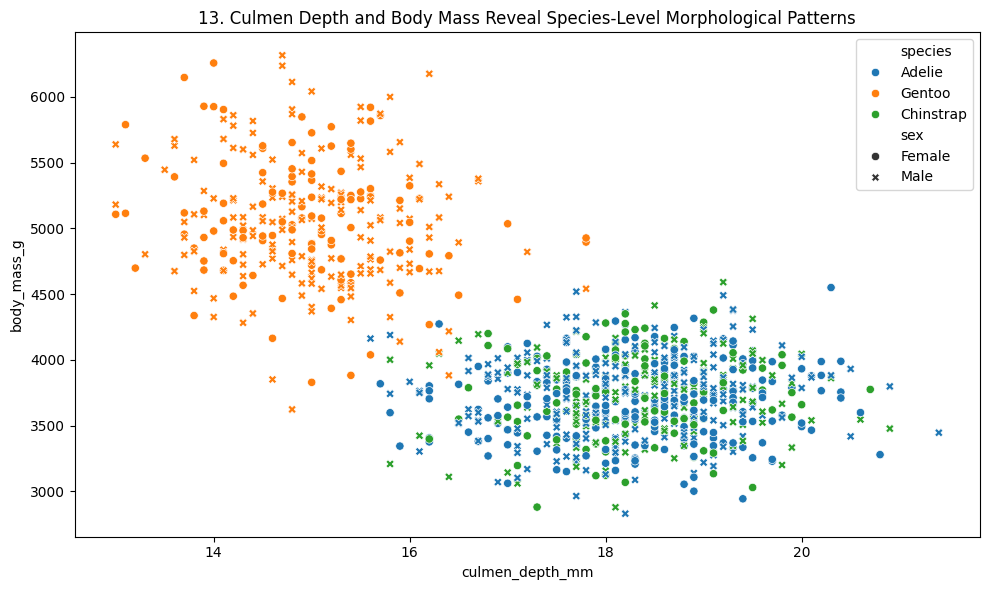

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='culmen_depth_mm', y='body_mass_g', hue='species', style='sex')
plt.title(f'{plot_no}. Culmen Depth and Body Mass Reveal Species-Level Morphological Patterns')
show_fig()
plot_no += 1

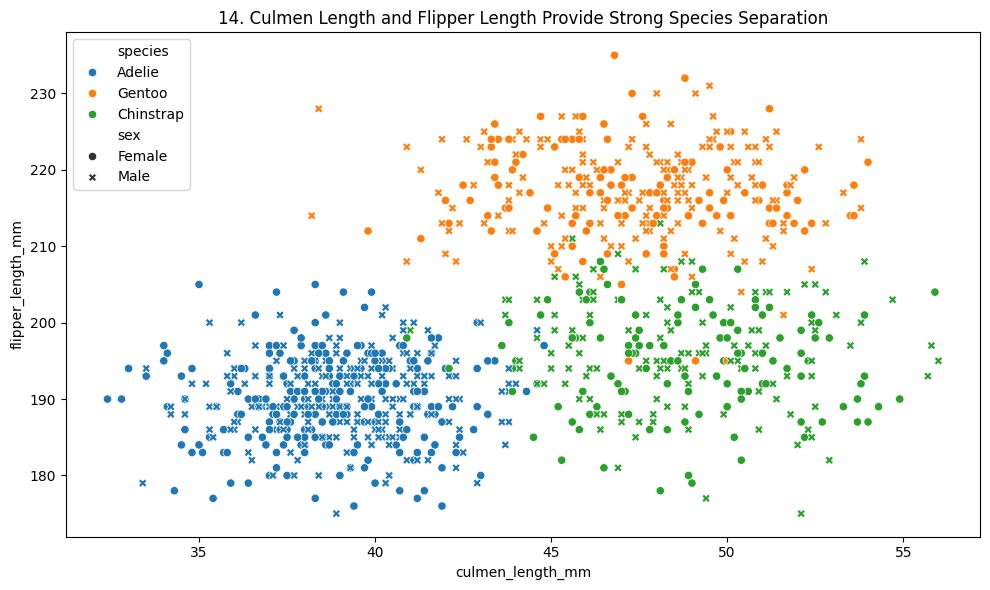

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='culmen_length_mm', y='flipper_length_mm', hue='species', style='sex')
plt.title(f'{plot_no}. Culmen Length and Flipper Length Provide Strong Species Separation')
show_fig()
plot_no += 1

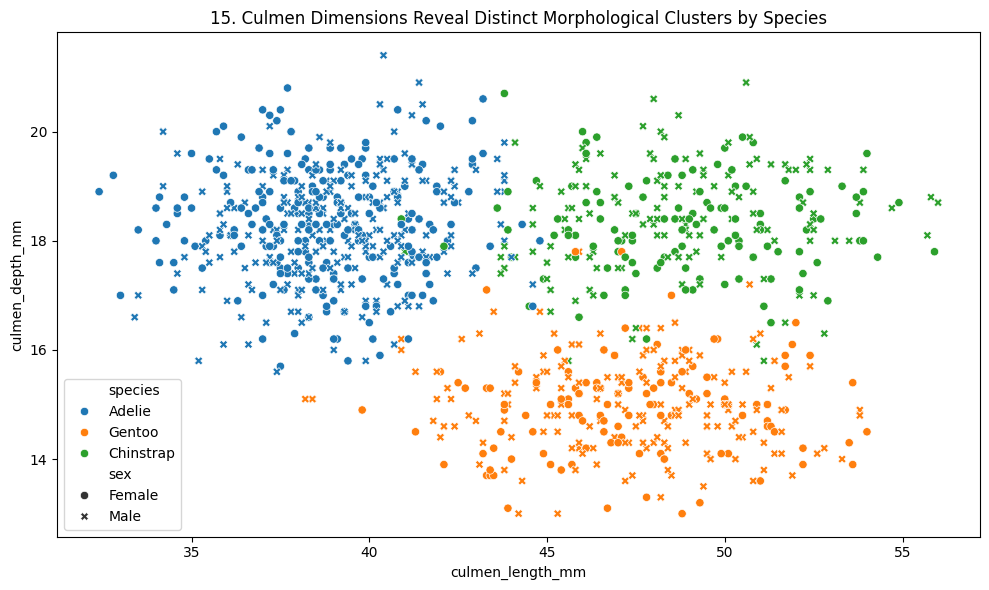

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='culmen_length_mm', y='culmen_depth_mm', hue='species', style='sex')
plt.title(f'{plot_no}. Culmen Dimensions Reveal Distinct Morphological Clusters by Species')
show_fig()
plot_no += 1

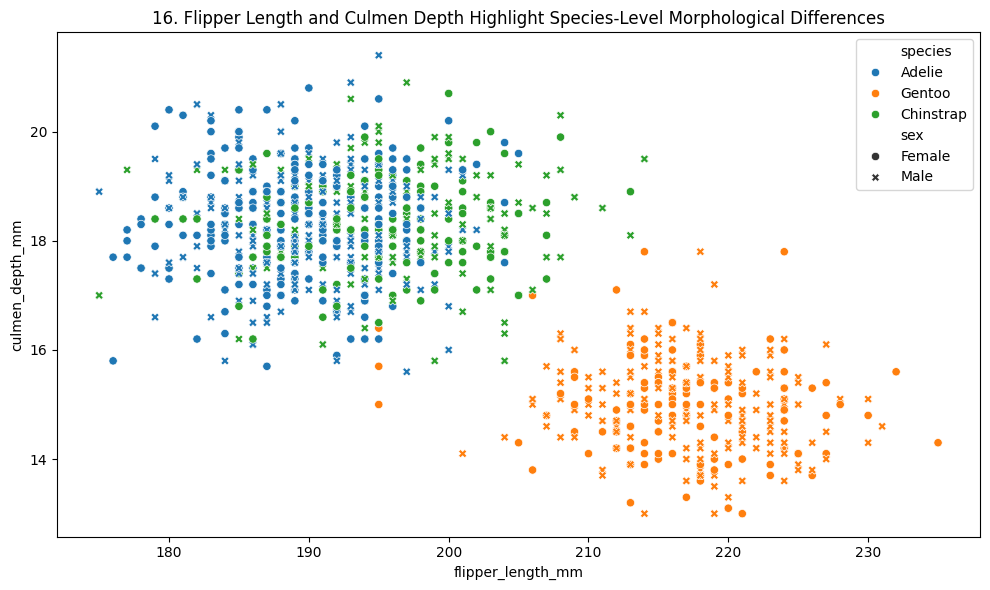

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='flipper_length_mm', y='culmen_depth_mm', hue='species', style='sex')
plt.title(f'{plot_no}. Flipper Length and Culmen Depth Highlight Species-Level Morphological Differences')
show_fig()
plot_no += 1

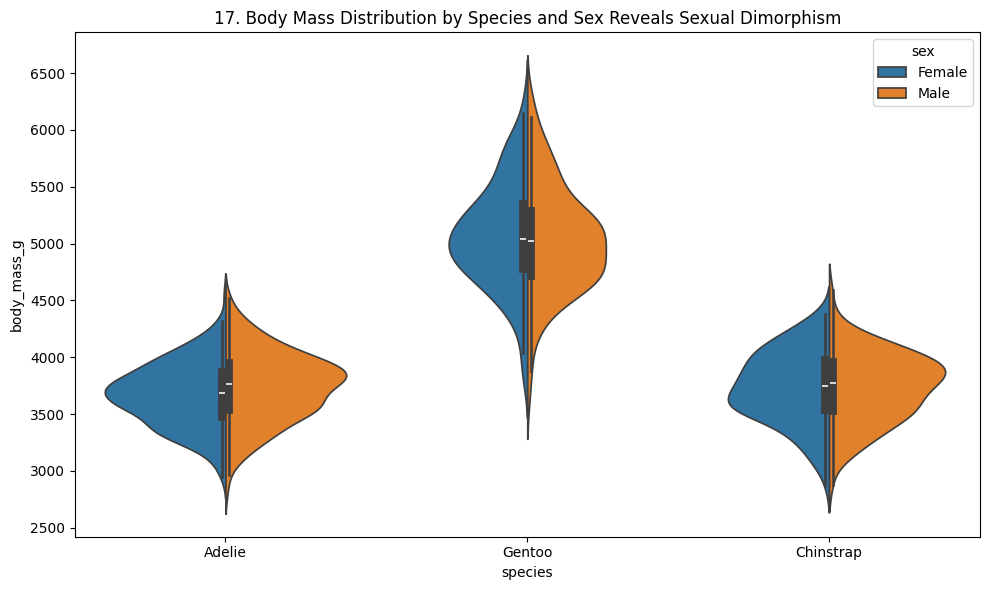

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='species', y='body_mass_g', hue='sex', split=True)
plt.title(f'{plot_no}. Body Mass Distribution by Species and Sex Reveals Sexual Dimorphism')
show_fig()
plot_no += 1

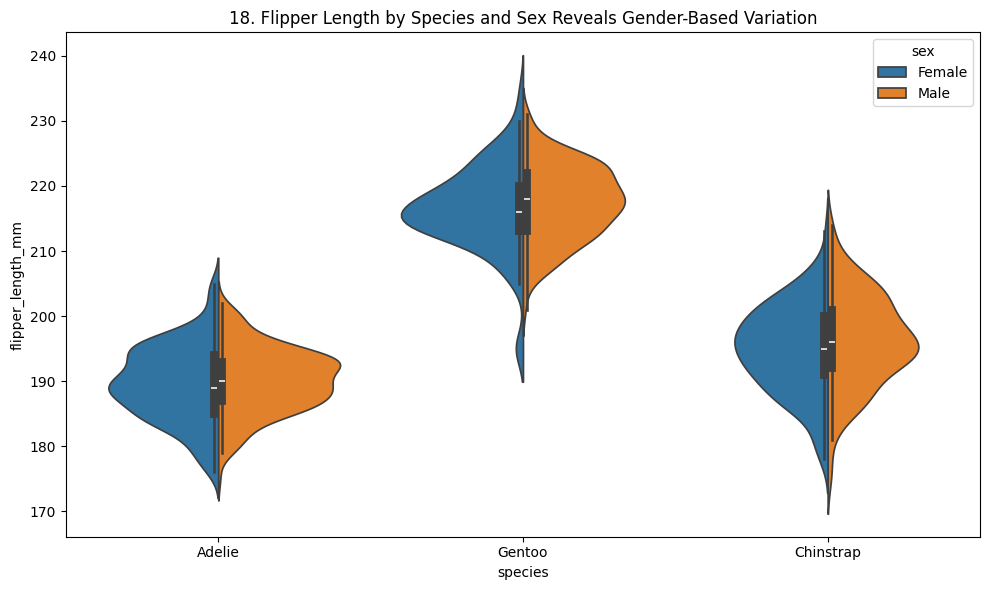

In [31]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='species', y='flipper_length_mm', hue='sex', split=True)
plt.title(f'{plot_no}. Flipper Length by Species and Sex Reveals Gender-Based Variation')
show_fig()
plot_no += 1

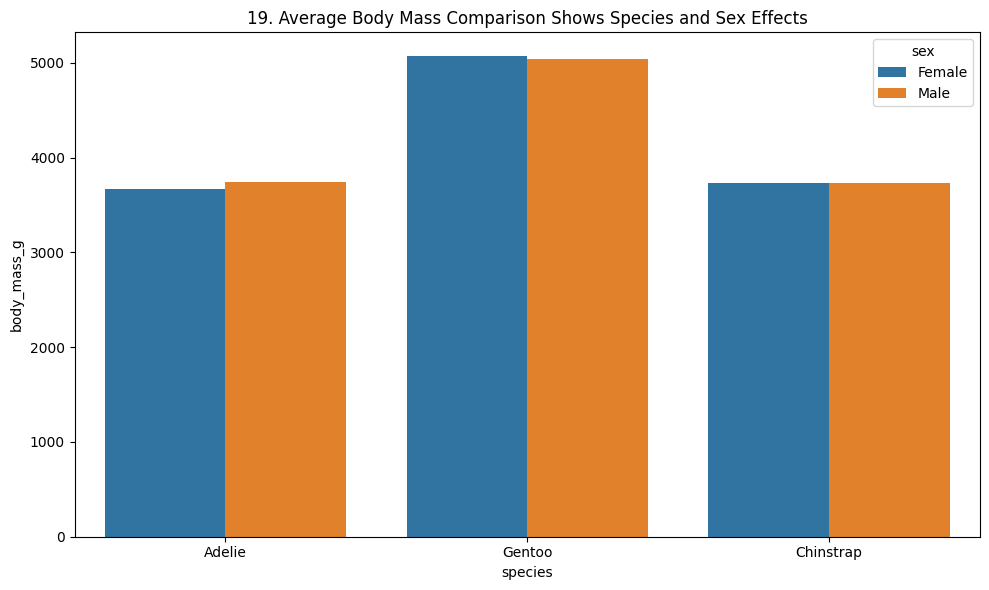

In [32]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='species', y='body_mass_g', hue='sex', errorbar=None)
plt.title(f'{plot_no}. Average Body Mass Comparison Shows Species and Sex Effects')
show_fig()
plot_no += 1

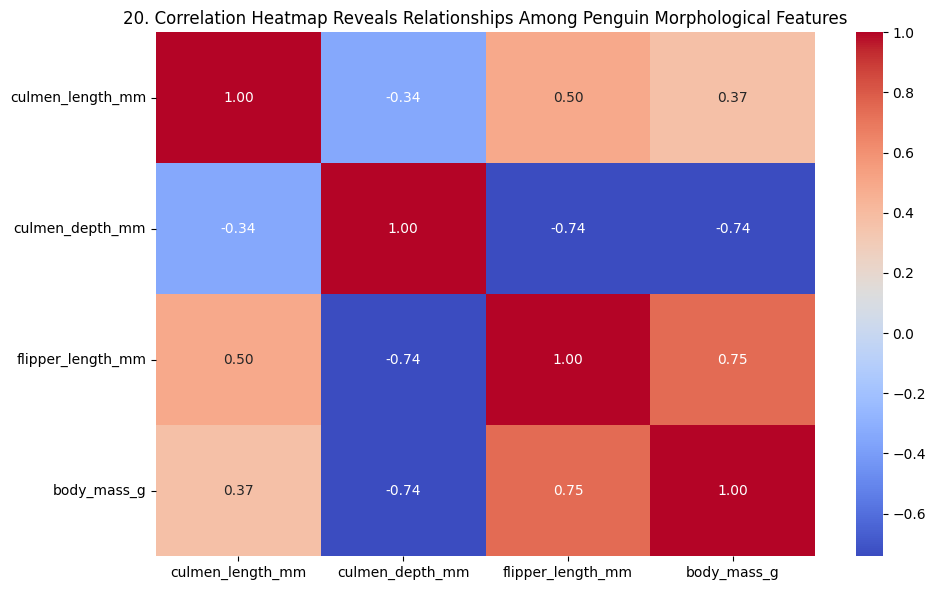

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap Reveals Relationships Among Penguin Morphological Features')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [34]:
X = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

## Encode target labels

In [35]:
le = LabelEncoder()
y = le.fit_transform(y)

## Split data into training and testing sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale numerical features and train Logistic Regression

In [37]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Predict test data

In [38]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 99.00%


## Display confusion matrix

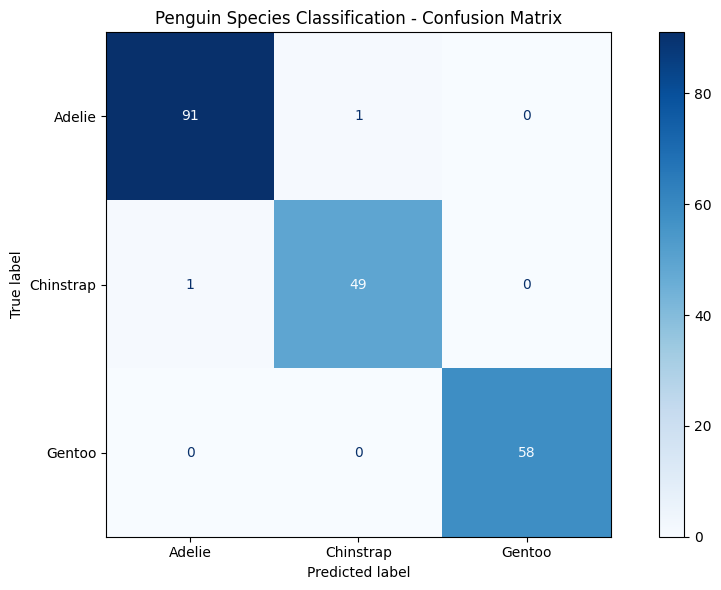

In [40]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), cmap='Blues')
plt.title('Penguin Species Classification - Confusion Matrix')
show_fig()